In [16]:
import math
import pickle

import datajoint as dj
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import ndimage
import scipy
import seaborn as sns
import torch
from tqdm import tqdm
from scipy.stats import wilcoxon, ttest_ind
from statsmodels.stats.multitest import multipletests

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

from featurevis.ops import center_and_crop_image, standardize_image
from staticnet_analyses import base, gabors
from staticnet_pilots.analyses import *
from staticnet_invariance import (
    dei_stimulus_reconfigured as dei_stimulus,
    deis_reconfigured as deis_schema,
    toy,
    toy_deis,
)
from staticnet_invariance.segmentation import find_cross

stimulus = dj.create_virtual_module('stimulus', 'pipeline_stimulus')
imagenet = dj.create_virtual_module('pipeline_imagenet', 'pipeline_imagenet')
experiment = dj.create_virtual_module('pipeline_experiment', 'pipeline_experiment')
meso = dj.create_virtual_module('pipeline_meso', 'pipeline_meso')
fuse = dj.create_virtual_module('fuse', 'pipeline_fuse')
collection = dj.create_virtual_module('collection', 'pipeline_collection')

# get manually curated neuron information 
with open('/dj-stor01/users/zhiwei/closed_loop_bad_matching_neurons_by_visual_inspection_on_summary_images.pickle', 'rb') as handle:
    manual_exclude_dic = pickle.load(handle)
    
def get_exclude_neurons(manual_exclude_dic, corr_thresh=0.42, dist_thresh=10, exclude_type='confusion', mei_key=None):
    if exclude_type == 'confusion':
        manual_exclude = manual_exclude_dic['{}-{}-{}'.format(*mei_key.values())]
        neuron_dics = (DEIClosedLoopSummaryResults.Neuron() & mei_key).fetch('neuron_id', 'matched_corr', 'matched_distance', as_dict=True, order_by='neuron_id')
        exclude_cols = [i for i, dic in enumerate(neuron_dics) if (dic['neuron_id'] in manual_exclude) or (dic['matched_corr'] < corr_thresh) or (dic['matched_distance'] > dist_thresh)]
        return exclude_cols
    else:
        manual_exclude = []
        for key, val in zip(manual_exclude_dic.keys(), manual_exclude_dic.values()):
            manual_exclude.extend([dict(animal_id=key.split('-')[0], session=key.split('-')[1], scan_idx=key.split('-')[2], neuron_id=n) for n in val])

        rel1 = DEIClosedLoopSummaryResults.Neuron & 'group_id in (241)'
        rel2 = DEIClosedLoopSummaryResults.Neuron & manual_exclude
        rel3 = DEIClosedLoopSummaryResults.Neuron & 'group_id not in (241) and matched_corr < {} or matched_distance > {}'.format(corr_thresh, dist_thresh)
        rel4 = DEIClosedLoopSummaryResults.Neuron & 'animal_id = 27470 and session = 7 and scan_idx = 12'
        # rel4 = DEIClosedLoopSummaryResults.Neuron & 'animal_id = 27470 and session = 6 and scan_idx = 8' # accidentally showed exact same stimuli for 27470-6-8 and 27470-7-12

        return rel1.proj() + rel2.proj() + rel3.proj() + rel4.proj()

def cal_dof(x,y):
    a = x.std()**2/len(x)
    b = y.std()**2/len(y)
    return (a+b)**2 / (a**2/(len(x)-1) + b**2/(len(y)-1))

# x,y has format n_pts*n_repeats(or observations)
def get_stat(x, y, alternative):
    print(wilcoxon(x.mean(axis=1),y.mean(axis=1), alternative=alternative))
    print('DOF: {:.2f}'.format(np.nanmean([cal_dof(i,j) for i,j in zip(x,y)])))

    stats = np.array([ttest_ind(i,j,equal_var=False, alternative=alternative) for i,j in zip(x,y)])
    temp = stats[:,0][stats[:,1]<0.05]
    print('Prior correction: Different {} {:.2f}% Less {} {:.2f}%, Greater {} {:.2f}%'.format(len(temp), len(temp)/len(x)*100, (temp<0).sum(), (temp<0).sum()/len(x)*100, (temp>0).sum(), (temp>0).sum()/len(x)*100))

    cr_temp = stats[:,0][multipletests(stats[:,1],0.05,method="fdr_bh")[0]]
    print('Post correction: Different {} {:.2f}% Less {} {:.2f}%, Greater {} {:.2f}%'.format(len(cr_temp), len(cr_temp)/len(x)*100, (cr_temp<0).sum(), (cr_temp<0).sum()/len(x)*100, (cr_temp>0).sum(), (cr_temp>0).sum()/len(x)*100))

## 2a

In [4]:
rest = 'group_id in (336, 337) and stim_type = "dei_multi_repeats"'
exclude = get_exclude_neurons(manual_exclude_dic, exclude_type='scatter')
neuron_rel = (DEIClosedLoopSummaryResults.Neuron - exclude)  
n_neurons = len(neuron_rel & (DEIClosedLoopSummaryResults.Subtype & rest))

In [5]:
groups, neurons, resps, subtypes = (DEIClosedLoopSummaryResults.Subtype & rest & neuron_rel).fetch('group_id', 'neuron_id', 'real_response', 'subtype', order_by='group_id, neuron_id, subtype')
resps = np.stack(resps).reshape(-1, 11, 20) # neurons * images * repeats

mei_mean = np.repeat((resps).mean(-1)[:, -1], 10)
mei_std = np.repeat((resps).std(-1, ddof=1)[:, -1], 10)
dei_mean = resps.mean(-1)[:, :-1].ravel()
dei_std = resps.std(-1, ddof=1)[:, :-1].ravel()
mei_r = np.stack([np.repeat(r, 10).reshape(20, -1).T for r in resps[:, -1]]).reshape(-1, 20)
dei_r = resps[:, :-1].reshape(-1, 20)

In [17]:
get_stat(mei_r*0.85, dei_r, 'greater')

WilcoxonResult(statistic=591361.0, pvalue=0.015194467352282373)
DOF: 32.47
Prior correction: Different 274 18.39% Less 0 0.00%, Greater 274 18.39%
Post correction: Different 44 2.95% Less 0 0.00%, Greater 44 2.95%


(-0.370413345731494, 7.778680260361373, -0.3471532416895003, 7.290218075479506)

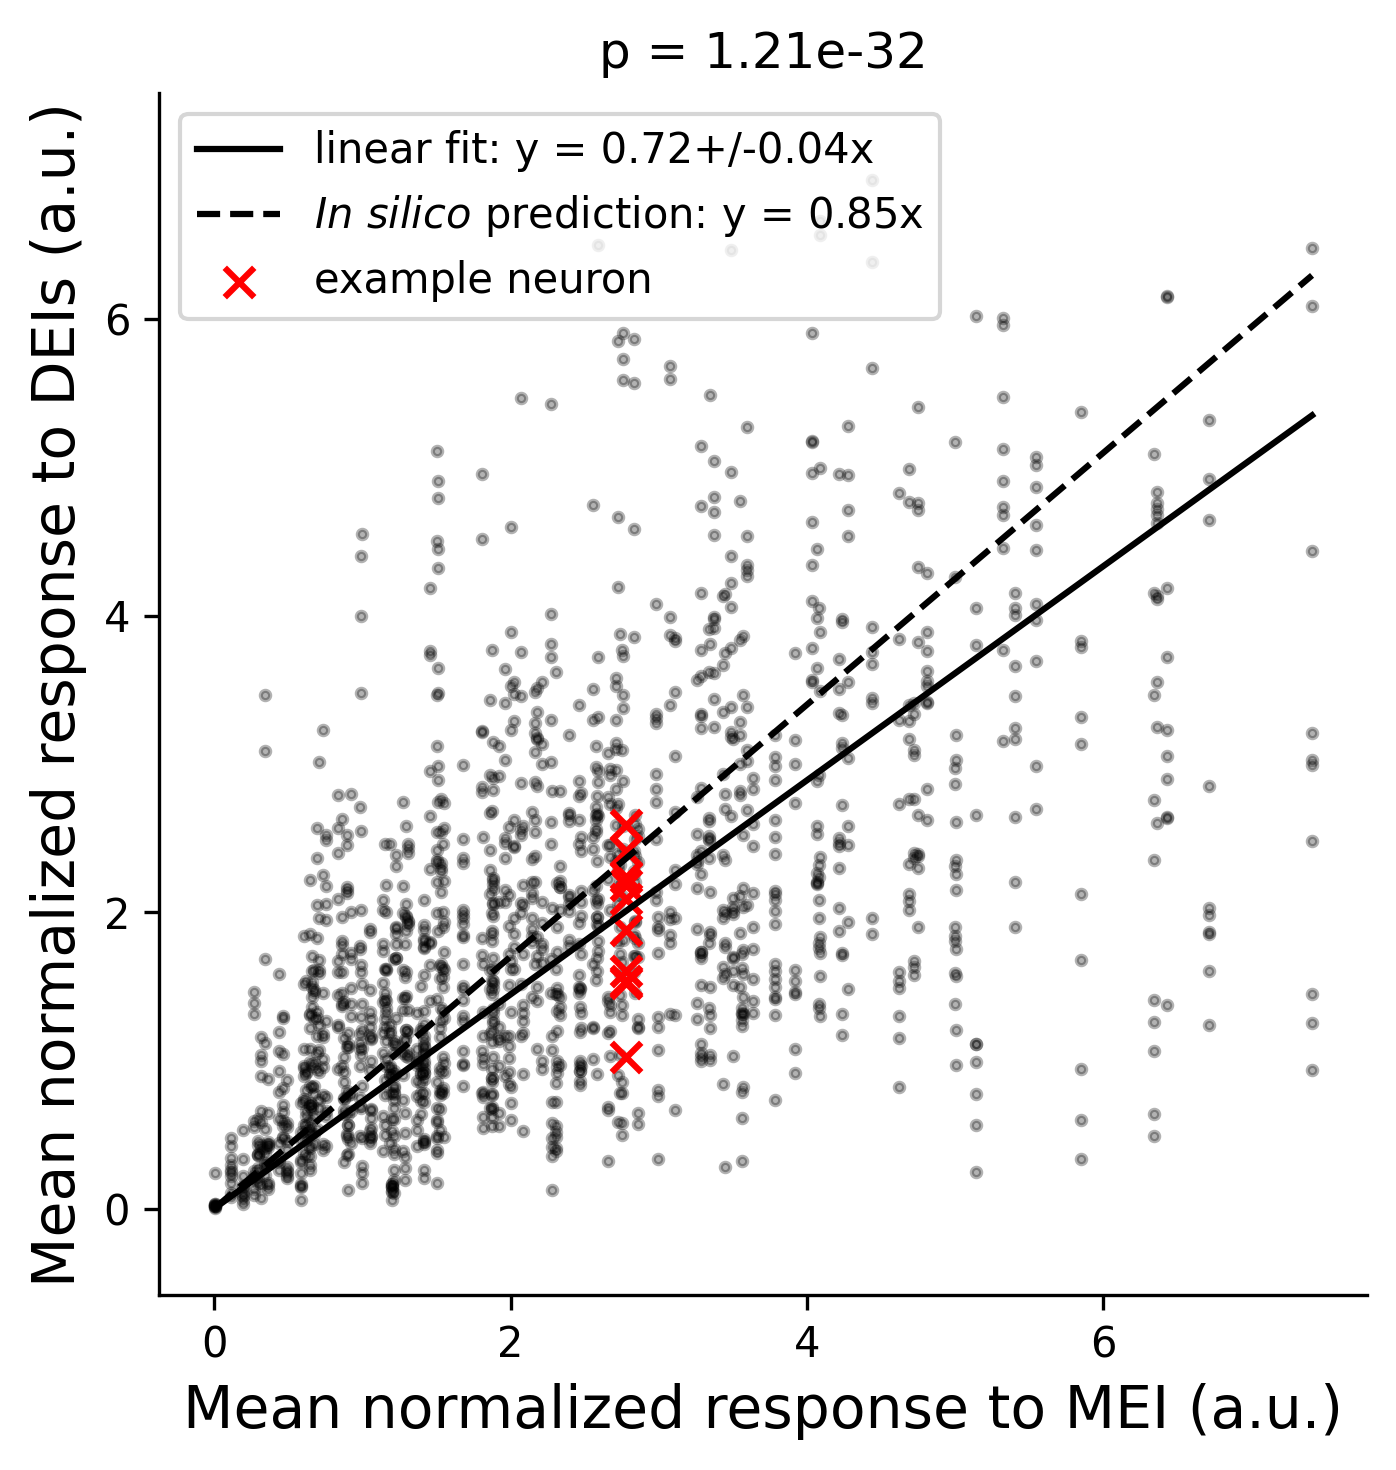

In [21]:
x = mei_mean
y = dei_mean
example_idxs = np.arange(900, 910)

scatterplot_helper(x, y, 'Mean normalized response to MEI (a.u.)', 'Mean normalized response to DEIs (a.u.)', get_bound_from_data=True, plot_identity=False, alpha=0.3, exclude_idxs_for_scatter=example_idxs)
max_val = np.concatenate([x, y]).max()
plt.plot([0, max_val], [0, max_val*0.85], color='k', linestyle='dashed', label='$In\ silico$ prediction: y = 0.85x')
plt.scatter(x[example_idxs], y[example_idxs], color='r', s=50, marker='x', label='example neuron')
plt.legend(loc=2)
plt.xticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])
plt.yticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])
plt.axis('equal')
# plt.savefig('/src/notebooks/Figures/DEI rebuttal/main/[Fig2]All_individual_DEIs_from_each_neuron_against_MEI_responses.pdf', transparent=True)


## 2e

In [439]:
all_mei_r, all_dei_single_r, all_dei_multi_r = [], [], []
for i in tqdm(range(10000)):
    mei_r, dei_single_r, dei_multi_r = [], [], []
    np.random.seed(i + 100000)
    neuron_idxs = np.random.choice(np.arange(149), 149, replace=True)
    for ni in neuron_idxs:
        # bootstrap mei trials
        mei_idxs = np.random.choice(np.arange(20), 20, replace=True)
        mei_r.append(resps[ni, -1, mei_idxs].mean())
        
        # bootstrap trials from 1 random single DEI
        image_idx = np.random.choice(np.arange(10), 1, replace=True)
        dei_idxs = np.random.choice(np.arange(20), 20, replace=True)
        dei_single_r.append(resps[ni, image_idx, dei_idxs].mean())
        
        # bootstrap trials from all 10 DEIs
        dei_idxs = np.random.choice(np.arange(200), 20, replace=True)
        dei_multi_r.append(resps[ni, :-1].ravel()[dei_idxs].mean())
    all_mei_r.append(mei_r)
    all_dei_single_r.append(dei_single_r)
    all_dei_multi_r.append(dei_multi_r)

100%|██████████| 10000/10000 [04:39<00:00, 35.79it/s]


In [440]:
from sklearn import linear_model
all_single_coefs, all_multi_coefs = [], []
for mei_r, dei_single_r, dei_multi_r in tqdm(zip(np.stack(all_mei_r), np.stack(all_dei_single_r), np.stack(all_dei_multi_r))):
    single_coefs, multi_coefs = [], []
    x = mei_r[:, np.newaxis]
    for i in range(1000):
        # single DEI fit
        ransac = linear_model.RANSACRegressor(base_estimator=linear_model.LinearRegression(fit_intercept=False), max_trials=1000)
        ransac.fit(x, dei_single_r)
        single_coefs.append(ransac.estimator_.coef_.item())
        
        # multi DEI fit
        ransac = linear_model.RANSACRegressor(base_estimator=linear_model.LinearRegression(fit_intercept=False), max_trials=1000)
        ransac.fit(x, dei_multi_r)
        multi_coefs.append(ransac.estimator_.coef_.item())
    
    all_single_coefs.append(np.mean(single_coefs))
    all_multi_coefs.append(np.mean(multi_coefs))


41it [08:13, 11.97s/it]/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_regression.py:796: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
115it [23:24, 12.59s/it]/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_regression.py:796: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
125it [25:22, 11.86s/it]/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_regression.py:796: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
154it [31:20, 13.04s/it]/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_regression.py:796: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_regression.py:796: UndefinedMetricWarning

In [457]:
dic = dict(single_dei_coef = all_single_coefs, multiple_dei_coef = all_multi_coefs)

In [450]:
import pickle
with open('/src/notebooks/DEI rebuttal/DEI_vs_MEI_linear_fit_coefs.pickle','wb') as handle:
    pickle.dump(dic,handle)

In [156]:
import pickle
with open('DEI_vs_MEI_linear_fit_coefs.pickle','rb') as handle:
    a = pickle.load(handle)
    
x = np.array(a['single_dei_coef'])
y = np.array(a['multiple_dei_coef'])
p = min(((x-y)>0).sum()/len(x),((x-y)<0).sum()/len(x))*2
print(p)

0.5892


In [157]:
np.median(x)

0.7069618503115723

In [158]:
np.median(y)

0.7639834356769408

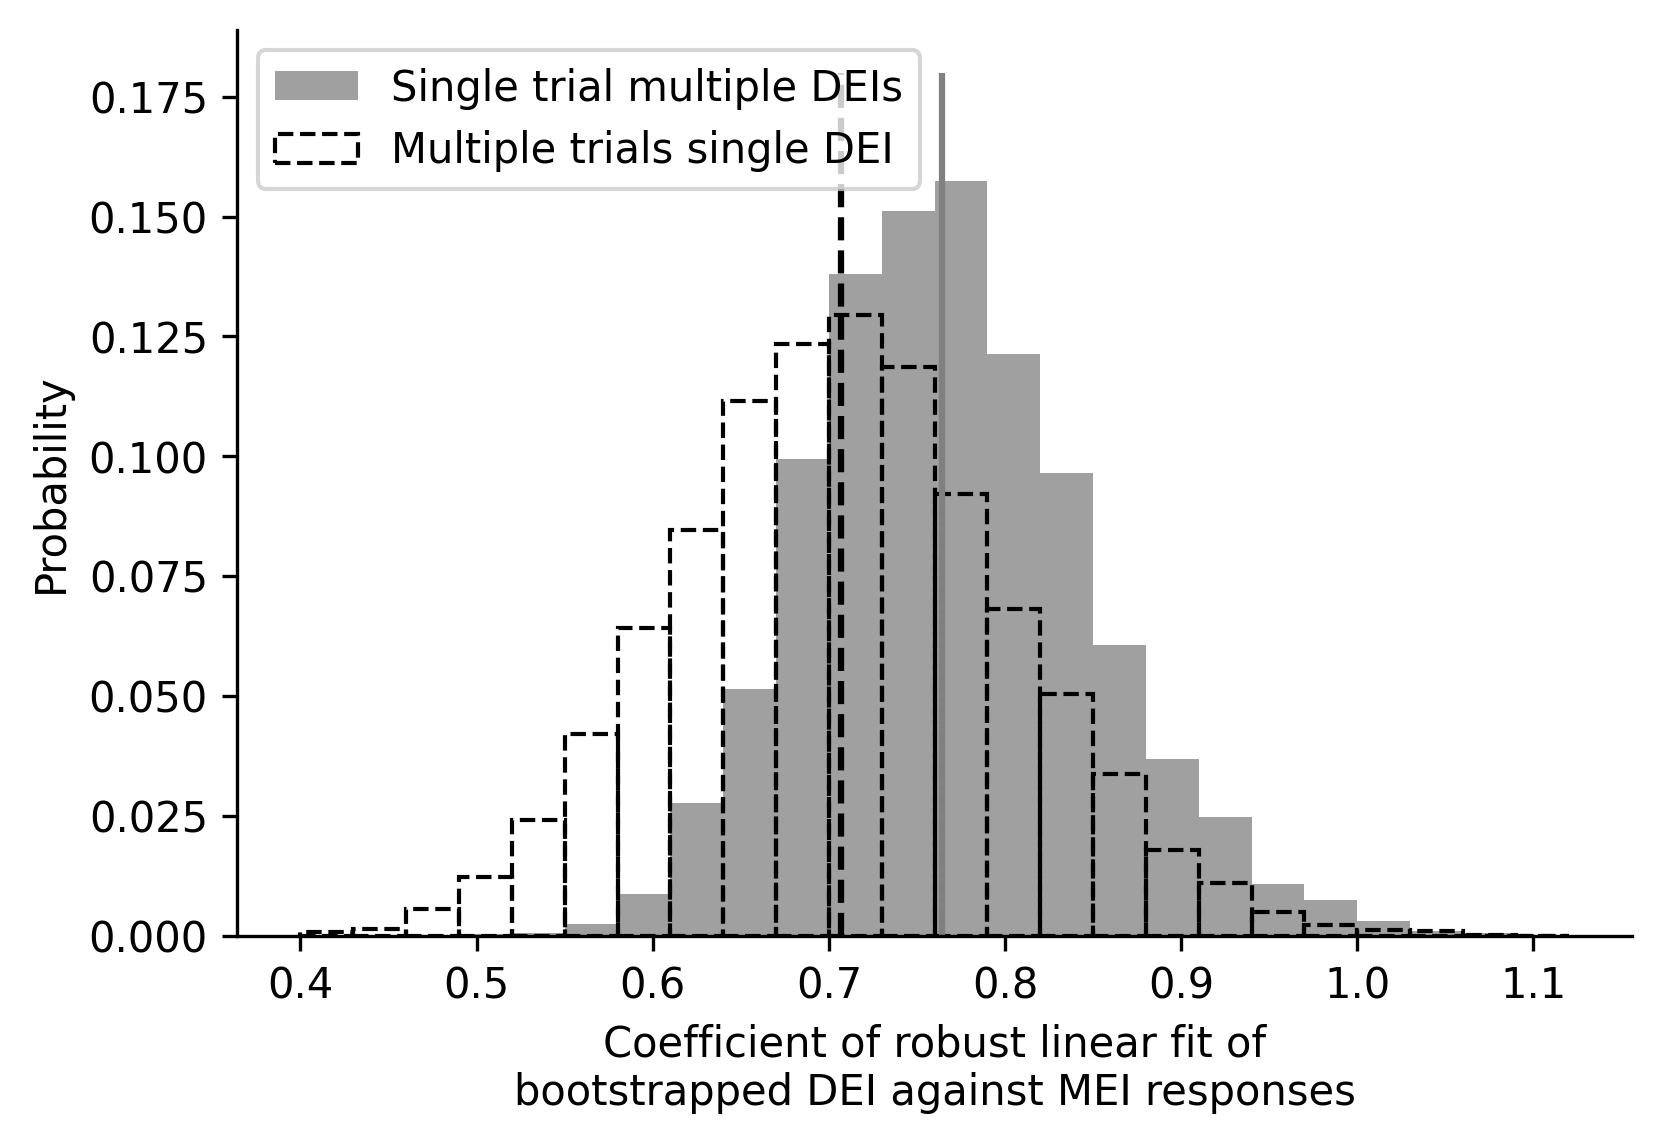

In [455]:
plt.figure(dpi=300)
sns.histplot(all_multi_coefs, stat='probability', binrange=[0.4, 1.1], binwidth=0.03, label='Single trial multiple DEIs', color='gray', linewidth=0)
sns.histplot(all_single_coefs, stat='probability', binrange=[0.4, 1.1], binwidth=0.03, label='Multiple trials single DEI', color='k', fill=False, linewidth=1, linestyle='dashed')
plt.xlabel('Coefficient of robust linear fit of\nbootstrapped DEI against MEI responses')
plt.legend()
plt.vlines(np.median(all_single_coefs), 0, 0.18, linestyle='dashed')
plt.vlines(np.median(all_multi_coefs), 0, 0.18, color='gray')
sns.despine()
# plt.gca().set_xticklabels([])
# plt.gca().set_yticklabels([])
# plt.ylabel('')
plt.savefig('/src/notebooks/Figures/DEI rebuttal/supplement/Histogram of Coefficient of robust linear fit of bootstrapped DEI against MEI responses.pdf', transparent=True)
